<a href="https://colab.research.google.com/github/argenviahouse-sys/aprendizajeautomatico1/blob/main/TransformarDatosParaClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset

Fuente


https://archive.ics.uci.edu/dataset/690/palmer+penguins-3


# Limpiando datos para mejorar el funcionamiento de modelos



## Carga y exploración inicial

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset directamente desde el biblioteca de seaborn
penguins = sns.load_dataset('penguins')

# 2. Exploración inicial: ¿Qué forma tienen nuestros datos?
print("Muestra de los primeros registros:")
display(penguins.head())

print("\nInformación general del dataset (atención a los valores nulos):")
penguins.info()

print("\nEstadísticas descriptivas (observen los rangos de 'flipper_length_mm' vs 'body_mass_g'):")
display(penguins.describe())

Muestra de los primeros registros:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female



Información general del dataset (atención a los valores nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB

Estadísticas descriptivas (observen los rangos de 'flipper_length_mm' vs 'body_mass_g'):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [ ]:
penguins.shape

(344, 7)

# EDA



## Valores perdidos

In [ ]:
# Contamos cuántos valores nulos hay por columna
print("Valores nulos por columna antes de la limpieza:")
print(penguins.isnull().sum())

# Decisión didáctica: Como son pocos registros frente al total, procedemos a eliminarlos.
# En un escenario real, aquí discutiríamos estrategias de imputación (media, mediana, KNN).
penguins_clean = penguins.dropna().copy()

print(f"\nDimensión original: {penguins.shape}")
print(f"Dimensión post-limpieza: {penguins_clean.shape}")

Valores nulos por columna antes de la limpieza:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Dimensión original: (344, 7)
Dimensión post-limpieza: (333, 7)


## Modelar: influencia de la transformación de los datos

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Seleccionamos nuestras características (features)
X = penguins_clean[['flipper_length_mm', 'body_mass_g']]

# ---------------------------------------------------------
# CAMINO A: Modelo con datos crudos (sin escalar)
# ---------------------------------------------------------
# Instanciamos y entrenamos el modelo
kmeans_raw = KMeans(n_clusters=3, random_state=123)
penguins_clean['cluster_raw'] = kmeans_raw.fit_predict(X)

# ---------------------------------------------------------
# CAMINO B: Modelo con datos procesados (estandarizados)
# ---------------------------------------------------------
# 1. Aplicamos StandardScaler: z = (x - u) / s
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Entrenamos un nuevo modelo sobre los datos escalados
kmeans_scaled = KMeans(n_clusters=3, random_state=123)
penguins_clean['cluster_scaled'] = kmeans_scaled.fit_predict(X_scaled)



### VISUALIZACIÓN DEL CONTRASTE

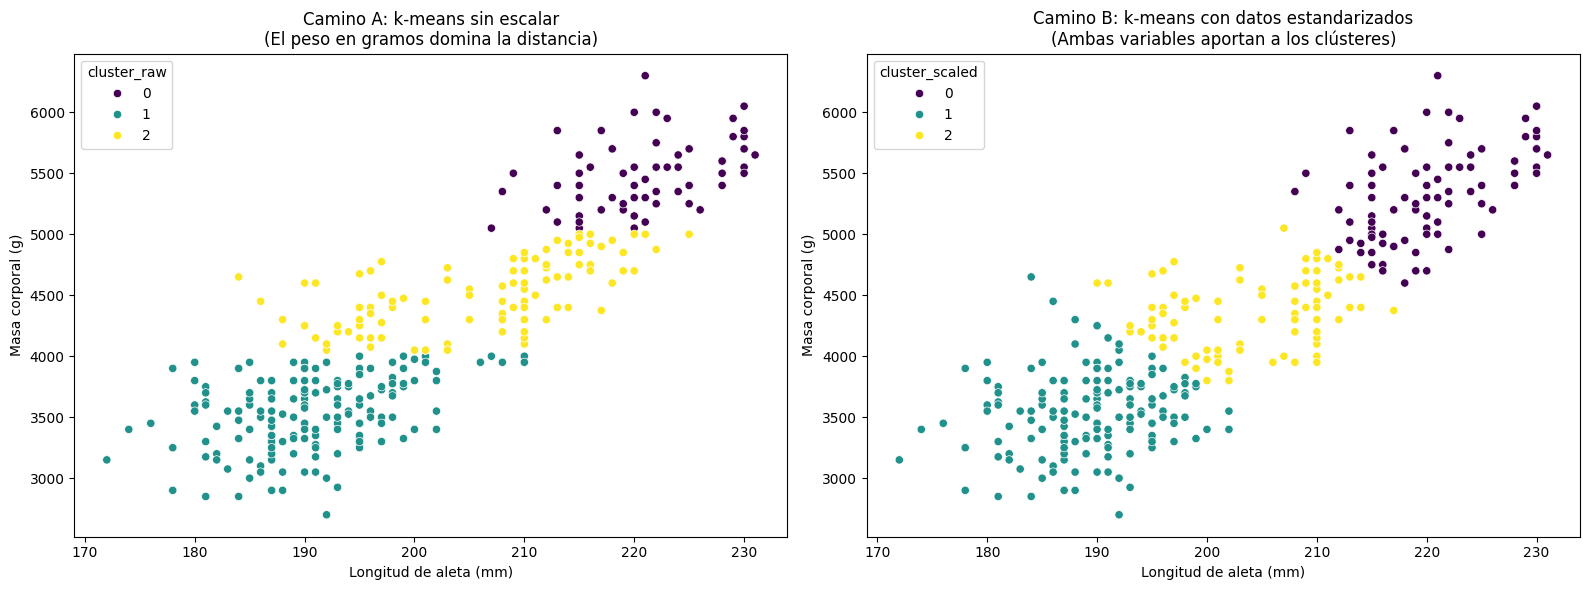

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: El fracaso de los datos crudos
sns.scatterplot(
    data=penguins_clean,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='cluster_raw',
    palette='viridis',
    ax=axes[0] # Corrected: use axes[0] for the first subplot
)
axes[0].set_title('Camino A: k-means sin escalar\n(El peso en gramos domina la distancia)')
axes[0].set_xlabel('Longitud de aleta (mm)')
axes[0].set_ylabel('Masa corporal (g)')

# Gráfico 2: El éxito del preprocesamiento
sns.scatterplot(
    data=penguins_clean,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='cluster_scaled',
    palette='viridis',
    ax=axes[1] # Corrected: use axes[1] for the second subplot
)
axes[1].set_title('Camino B: k-means con datos estandarizados\n(Ambas variables aportan a los clústeres)')
axes[1].set_xlabel('Longitud de aleta (mm)')
axes[1].set_ylabel('Masa corporal (g)')

plt.tight_layout()
plt.show()